# **Day 77: Uncertainty Quantification and Conformal Prediction**
*Module 12 - Trustworthy ML and MLOps*

A prediction without uncertainty is incomplete. A biomass map that says "120 t/ha" is far less useful than "120 t/ha, 90% interval 85-160 t/ha". Decision makers, reviewers and downstream models (carbon accounting, risk) need to know **how much to trust each prediction**, and where the model is extrapolating.

> A prediction is more useful with an honest uncertainty. Conformal prediction wraps any model and produces intervals or sets that contain the true answer with a guaranteed probability, for example 90%.
>
> *Example:* Instead of "biomass = 150 Mg/ha", the model says "between 120 and 185 Mg/ha with 90% confidence".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
torch.manual_seed(77); rng = np.random.default_rng(77)

## **1. Two Kinds of Uncertainty**
- **Aleatoric**: irreducible noise in the data (sensor noise, natural variability). More data does **not** remove it.
- **Epistemic**: the model's ignorance, large where training data are sparse or absent (extrapolation). More data **reduces** it.

A 1-D example where noise grows with x, and there is a **gap** in the training data (2.5-4) and nothing beyond x = 6.

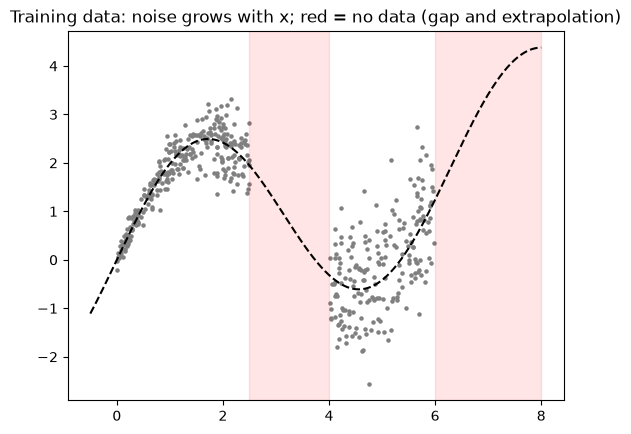

In [2]:
def f(x): return np.sin(x) * 2 + 0.3 * x
x_all = np.r_[rng.uniform(0, 2.5, 300), rng.uniform(4, 6, 200)]
y_all = f(x_all) + rng.normal(0, 0.1 + 0.15 * x_all)                          # heteroscedastic noise
x_grid = np.linspace(-0.5, 8, 400)
Xtr, Xcal, ytr, ycal = train_test_split(x_all[:, None], y_all, test_size=0.3, random_state=0)
plt.scatter(x_all, y_all, s=5, c="grey"); plt.plot(x_grid, f(x_grid), "k--"); plt.axvspan(2.5, 4, alpha=0.1, color="r"); plt.axvspan(6, 8, alpha=0.1, color="r")
plt.title("Training data: noise grows with x; red = no data (gap and extrapolation)"); plt.show()

## **2. Methods**

### (a) Quantile regression (aleatoric)
Predict the 5th and 95th percentiles directly (Day 26).

In [3]:
qlo = GradientBoostingRegressor(loss="quantile", alpha=0.05, n_estimators=300, max_depth=3, random_state=0).fit(Xtr, ytr)
qhi = GradientBoostingRegressor(loss="quantile", alpha=0.95, n_estimators=300, max_depth=3, random_state=0).fit(Xtr, ytr)
qmed = GradientBoostingRegressor(loss="quantile", alpha=0.5, n_estimators=300, max_depth=3, random_state=0).fit(Xtr, ytr)

### (b) Deep ensembles (epistemic + aleatoric)
Lakshminarayanan et al. (2017): train M networks from different random initialisations; each predicts a mean **and** a variance (Gaussian negative log-likelihood loss). Disagreement between members = epistemic uncertainty; predicted variances = aleatoric.

In [4]:
class GaussianMLP(nn.Module):
    def __init__(self, h=64, p_drop=0.0):
        super().__init__(); self.net = nn.Sequential(nn.Linear(1, h), nn.Tanh(), nn.Dropout(p_drop), nn.Linear(h, h), nn.Tanh(), nn.Dropout(p_drop), nn.Linear(h, 2))
    def forward(self, x):
        out = self.net(x); return out[:, 0], F.softplus(out[:, 1]) + 1e-4               # mean, variance

def train_gauss(model, X, y, epochs=1500, lr=5e-3):
    X, y = torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32); opt = torch.optim.Adam(model.parameters(), lr)
    for _ in range(epochs):
        mu, var = model(X); loss = F.gaussian_nll_loss(mu, y, var); opt.zero_grad(); loss.backward(); opt.step()
    return model

ensemble = []
for m in range(5):
    torch.manual_seed(m); ensemble.append(train_gauss(GaussianMLP(), Xtr, ytr))
Xg = torch.tensor(x_grid[:, None], dtype=torch.float32)
with torch.no_grad():
    mus = torch.stack([e(Xg)[0] for e in ensemble]).numpy(); vars_ = torch.stack([e(Xg)[1] for e in ensemble]).numpy()
ens_mu = mus.mean(0); aleatoric = vars_.mean(0); epistemic = mus.var(0); ens_sd = np.sqrt(aleatoric + epistemic)

### (c) MC dropout (cheap approximate Bayesian inference)
Keep dropout **on** at test time and run many stochastic forward passes (Gal & Ghahramani, 2016); the spread approximates epistemic uncertainty.

In [5]:
torch.manual_seed(0); mc = train_gauss(GaussianMLP(p_drop=0.1), Xtr, ytr); mc.train()            # dropout active
with torch.no_grad():
    draws = torch.stack([mc(Xg)[0] for _ in range(200)]).numpy(); var_mc = torch.stack([mc(Xg)[1] for _ in range(200)]).numpy().mean(0)
mc_mu, mc_sd = draws.mean(0), np.sqrt(draws.var(0) + var_mc)

### (d) Random-forest spread (tree variance)

In [6]:
rf = RandomForestRegressor(500, min_samples_leaf=5, random_state=0).fit(Xtr, ytr)
tree_preds = np.stack([t.predict(x_grid[:, None]) for t in rf.estimators_]); rf_mu, rf_sd = tree_preds.mean(0), tree_preds.std(0)

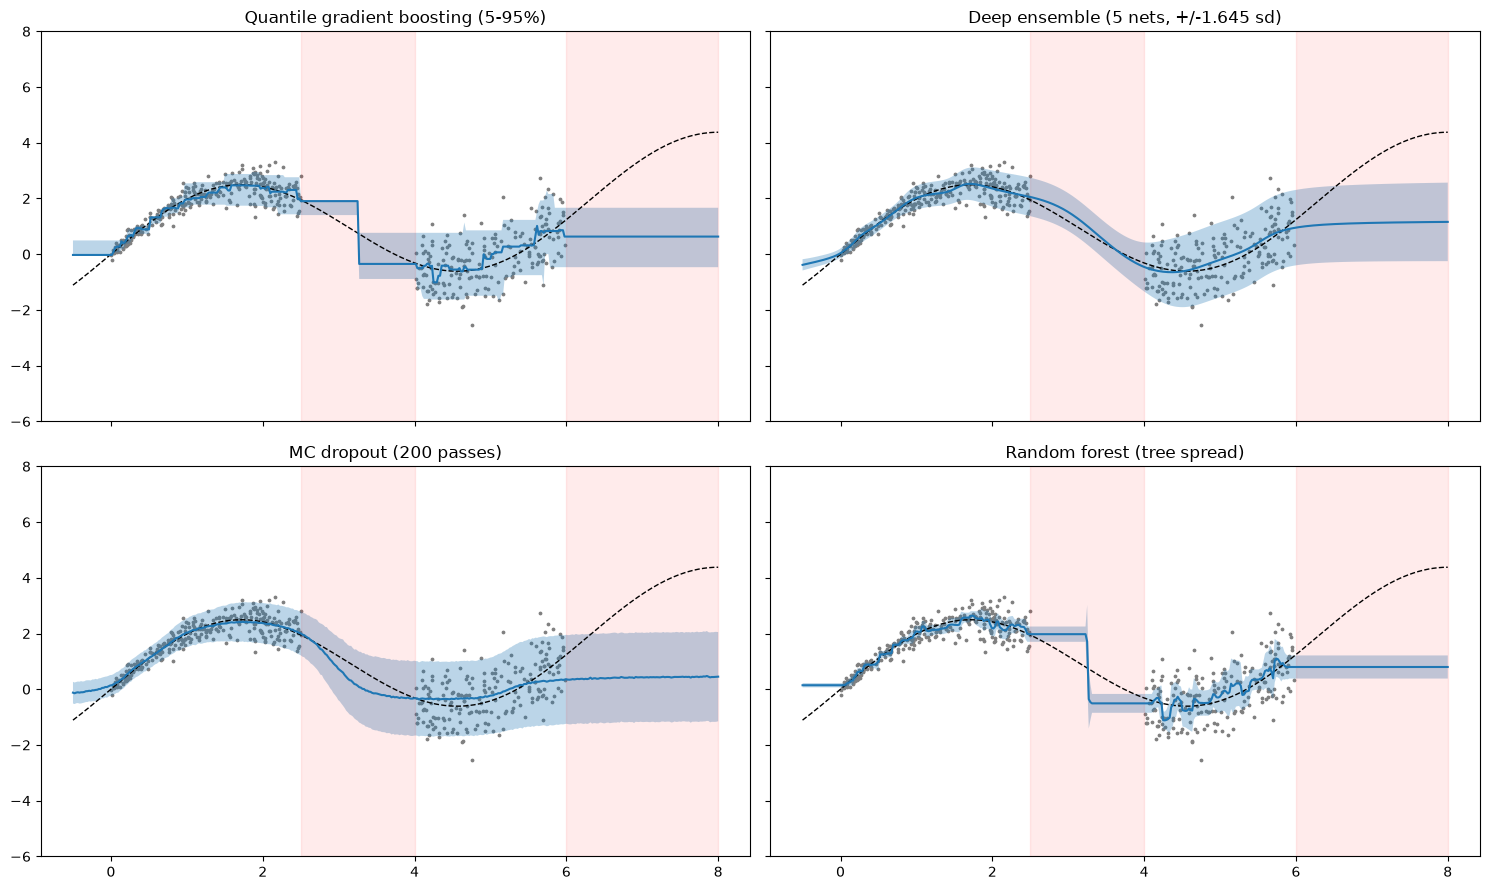

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)
panels = [("Quantile gradient boosting (5-95%)", qmed.predict(x_grid[:, None]), qlo.predict(x_grid[:, None]), qhi.predict(x_grid[:, None])),
          ("Deep ensemble (5 nets, +/-1.645 sd)", ens_mu, ens_mu - 1.645 * ens_sd, ens_mu + 1.645 * ens_sd),
          ("MC dropout (200 passes)", mc_mu, mc_mu - 1.645 * mc_sd, mc_mu + 1.645 * mc_sd),
          ("Random forest (tree spread)", rf_mu, rf_mu - 1.645 * rf_sd, rf_mu + 1.645 * rf_sd)]
for ax, (name, mid, lo, hi) in zip(axes.ravel(), panels):
    ax.scatter(x_all, y_all, s=3, c="grey"); ax.plot(x_grid, f(x_grid), "k--", lw=1); ax.plot(x_grid, mid, "C0"); ax.fill_between(x_grid, lo, hi, alpha=0.3)
    ax.axvspan(2.5, 4, alpha=0.08, color="r"); ax.axvspan(6, 8, alpha=0.08, color="r"); ax.set_title(name); ax.set_ylim(-6, 8)
plt.tight_layout(); plt.show()

- Quantile regression captures the **growing noise** but its band does not widen in the gap or beyond the data (it has no notion of epistemic uncertainty).
- The deep ensemble widens where members **disagree**: in the gap and when extrapolating.
- Tree-based spreads stay flat beyond the data (trees cannot extrapolate and all trees agree on the edge leaf): beware of over-confidence in extrapolation.

### Decomposing the ensemble's uncertainty

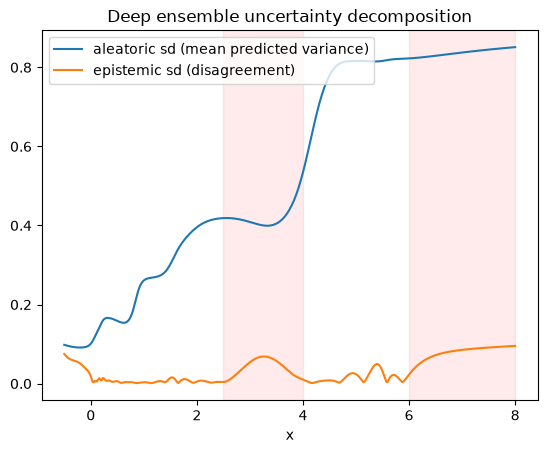

In [8]:
plt.plot(x_grid, np.sqrt(aleatoric), label="aleatoric sd (mean predicted variance)"); plt.plot(x_grid, np.sqrt(epistemic), label="epistemic sd (disagreement)")
plt.axvspan(2.5, 4, alpha=0.08, color="r"); plt.axvspan(6, 8, alpha=0.08, color="r"); plt.legend(); plt.xlabel("x"); plt.title("Deep ensemble uncertainty decomposition"); plt.show()

## **3. Conformal Prediction: Guaranteed Coverage**
Model-based intervals are only as good as their assumptions. **Split conformal prediction** (Vovk et al., 2005; Angelopoulos & Bates, 2023) wraps **any** model and gives intervals with guaranteed coverage $\ge 1-\alpha$ if calibration and test data are exchangeable (no distributional assumptions):
1. Fit the model on a training set.
2. On a separate **calibration** set compute nonconformity scores $s_i = |y_i - \hat f(x_i)|$.
3. Let $\hat q$ = the $\lceil(n+1)(1-\alpha)\rceil/n$ quantile of the scores.
4. Prediction interval: $\hat f(x)\pm\hat q$.

In [9]:
def split_conformal(model, X_cal, y_cal, alpha=0.1):
    scores = np.abs(y_cal - model.predict(X_cal)); n = len(scores)
    return np.quantile(scores, np.ceil((n + 1) * (1 - alpha)) / n, method="higher")
gbr = HistGradientBoostingRegressor(random_state=0).fit(Xtr, ytr)
qhat = split_conformal(gbr, Xcal, ycal, alpha=0.1)
x_te = np.r_[rng.uniform(0, 2.5, 2000), rng.uniform(4, 6, 1500)]; y_te = f(x_te) + rng.normal(0, 0.1 + 0.15 * x_te)
pred_te = gbr.predict(x_te[:, None])
print(f"conformal half-width {qhat:.3f} | empirical coverage on new data: {np.mean(np.abs(y_te - pred_te) <= qhat):.3f} (target 0.90)")

conformal half-width 1.032 | empirical coverage on new data: 0.894 (target 0.90)


The guarantee is **marginal** (on average over x), so a constant-width interval over-covers where noise is small and under-covers where it is large:

In [10]:
bins = pd.cut(x_te, [0, 1, 2, 2.5, 4, 5, 6])
cov = pd.Series(np.abs(y_te - pred_te) <= qhat).groupby(bins, observed=True).mean()
print("coverage by x range (constant-width conformal):\n", cov.round(3))

coverage by x range (constant-width conformal):
 (0.0, 1.0]    1.000
(1.0, 2.0]    0.991
(2.0, 2.5]    0.980
(4.0, 5.0]    0.798
(5.0, 6.0]    0.725
dtype: float64


## **4. Conformalised Quantile Regression (CQR): Adaptive Intervals**
Romano et al. (2019): start from quantile-regression intervals $[\hat q_{lo}(x), \hat q_{hi}(x)]$ and correct them with conformal calibration: score $s_i = \max(\hat q_{lo}(x_i) - y_i,\; y_i - \hat q_{hi}(x_i))$. Intervals adapt to local noise **and** keep the coverage guarantee.

In [11]:
lo_m = HistGradientBoostingRegressor(loss="quantile", quantile=0.05, random_state=0).fit(Xtr, ytr)
hi_m = HistGradientBoostingRegressor(loss="quantile", quantile=0.95, random_state=0).fit(Xtr, ytr)
s_cal = np.maximum(lo_m.predict(Xcal) - ycal, ycal - hi_m.predict(Xcal)); n = len(s_cal)
q_cqr = np.quantile(s_cal, np.ceil((n + 1) * 0.9) / n, method="higher")
lo_te, hi_te = lo_m.predict(x_te[:, None]) - q_cqr, hi_m.predict(x_te[:, None]) + q_cqr
inside = (y_te >= lo_te) & (y_te <= hi_te)
print(f"CQR coverage {inside.mean():.3f} | mean width {np.mean(hi_te - lo_te):.3f} (constant conformal width {2 * qhat:.3f})")
print("CQR coverage by x range:\n", pd.Series(inside).groupby(bins, observed=True).mean().round(3))

CQR coverage 0.903 | mean width 1.817 (constant conformal width 2.064)
CQR coverage by x range:
 (0.0, 1.0]    0.977
(1.0, 2.0]    0.944
(2.0, 2.5]    0.924
(4.0, 5.0]    0.867
(5.0, 6.0]    0.801
dtype: float64


## **5. Conformal Classification: Prediction Sets**
For classification, conformal prediction returns a **set** of classes that contains the true class with probability $\ge 1-\alpha$. Ambiguous samples get larger sets: an honest "it is cropland or grassland".

In [12]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
Xc, yc = make_classification(4000, 10, n_informative=6, n_classes=5, n_clusters_per_class=1, class_sep=0.8, random_state=1)
Xc_tr, Xc_rest, yc_tr, yc_rest = train_test_split(Xc, yc, test_size=0.5, random_state=0)
Xc_cal, Xc_te, yc_cal, yc_te = train_test_split(Xc_rest, yc_rest, test_size=0.5, random_state=0)
clf = LogisticRegression(max_iter=3000).fit(Xc_tr, yc_tr)
s = 1 - clf.predict_proba(Xc_cal)[np.arange(len(yc_cal)), yc_cal]                   # score: 1 - prob of the true class
n = len(s); q_cls = np.quantile(s, np.ceil((n + 1) * 0.9) / n, method="higher")
sets = clf.predict_proba(Xc_te) >= 1 - q_cls
print(f"top-1 accuracy {clf.score(Xc_te, yc_te):.3f} | conformal set coverage {sets[np.arange(len(yc_te)), yc_te].mean():.3f} (target 0.90)")
print("distribution of set sizes:", {int(k): int(v) for k, v in zip(*np.unique(sets.sum(1), return_counts=True))})

top-1 accuracy 0.639 | conformal set coverage 0.908 (target 0.90)
distribution of set sizes: {1: 195, 2: 513, 3: 259, 4: 30, 5: 3}


## **6. Evaluating Uncertainty**
- **Coverage** (should match the nominal level) and **mean width** (sharper is better, given coverage).
- **Calibration plot** for intervals: nominal vs observed coverage across levels.
- **Proper scores**: Gaussian NLL, **CRPS** (continuous ranked probability score) reward both calibration and sharpness.
- **Uncertainty vs error**: higher predicted uncertainty should go with higher actual error (sparsification / ranking plots).

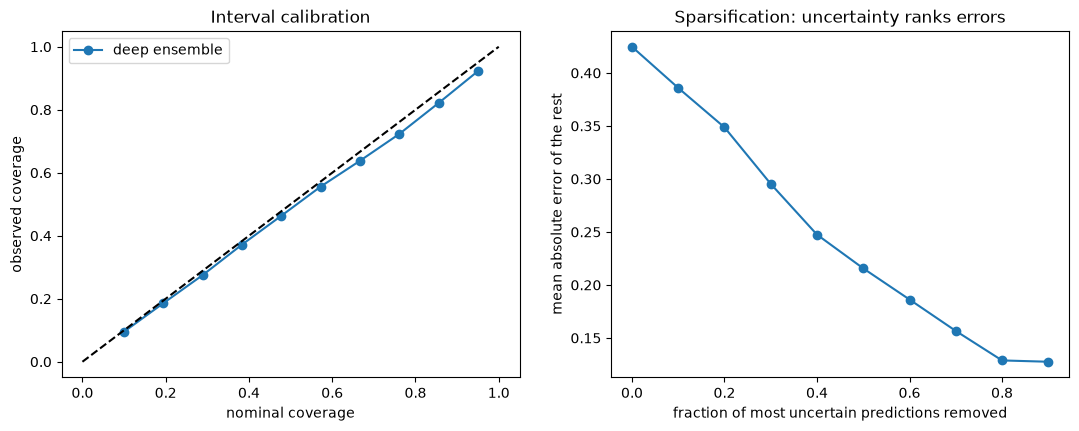

CRPS of the deep ensemble (Gaussian closed form): -0.024 (lower is better)


In [13]:
from scipy.stats import norm
with torch.no_grad():
    m_te = np.stack([e(torch.tensor(x_te[:, None], dtype=torch.float32))[0].numpy() for e in ensemble]); v_te = np.stack([e(torch.tensor(x_te[:, None], dtype=torch.float32))[1].numpy() for e in ensemble])
mu_e, sd_e = m_te.mean(0), np.sqrt(v_te.mean(0) + m_te.var(0))
levels = np.linspace(0.1, 0.95, 10)
obs = [np.mean(np.abs(y_te - mu_e) <= norm.ppf(0.5 + l / 2) * sd_e) for l in levels]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(levels, obs, "o-", label="deep ensemble"); axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set(xlabel="nominal coverage", ylabel="observed coverage", title="Interval calibration"); axes[0].legend()
order = np.argsort(sd_e)[::-1]; err = np.abs(y_te - mu_e)
fracs = np.linspace(0, 0.9, 10); axes[1].plot(fracs, [err[order[int(fr * len(err)):]].mean() for fr in fracs], "o-")
axes[1].set(xlabel="fraction of most uncertain predictions removed", ylabel="mean absolute error of the rest", title="Sparsification: uncertainty ranks errors"); plt.show()
crps = np.mean(sd_e * (np.abs(y_te - mu_e) / sd_e * (2 * norm.cdf((y_te - mu_e) / sd_e) - 1) + 2 * norm.pdf((y_te - mu_e) / sd_e) - 1 / np.sqrt(np.pi)))
print(f"CRPS of the deep ensemble (Gaussian closed form): {crps:.3f} (lower is better)")

# **Part 2: Going Deeper - Uncertainty Under Shift**

Conformal guarantees require **exchangeability**. Under distribution shift (a new region, a new season) they can fail. And spatially autocorrelated calibration data near the training data give over-optimistic calibration. Remedies: calibrate on data from the **target domain**, use **spatially separated** calibration sets, weighted conformal prediction for covariate shift (Tibshirani et al., 2019), and flag inputs outside the training distribution (the **area of applicability**, Day 88).

In [14]:
x_shift = rng.uniform(6.5, 8, 1000); y_shift = f(x_shift) + rng.normal(0, 0.1 + 0.15 * x_shift)
lo_s, hi_s = lo_m.predict(x_shift[:, None]) - q_cqr, hi_m.predict(x_shift[:, None]) + q_cqr
with torch.no_grad():
    ms = np.stack([e(torch.tensor(x_shift[:, None], dtype=torch.float32))[0].numpy() for e in ensemble]); vs = np.stack([e(torch.tensor(x_shift[:, None], dtype=torch.float32))[1].numpy() for e in ensemble])
sd_s = np.sqrt(vs.mean(0) + ms.var(0))
print(f"Extrapolation region x in [6.5, 8]: CQR coverage {np.mean((y_shift >= lo_s) & (y_shift <= hi_s)):.3f} | deep-ensemble 90% coverage {np.mean(np.abs(y_shift - ms.mean(0)) <= 1.645 * sd_s):.3f}")
print(f"epistemic sd: in-domain mean {np.sqrt(m_te.var(0)).mean():.3f} vs extrapolation {np.sqrt(ms.var(0)).mean():.3f}  <- a useful out-of-distribution flag")

Extrapolation region x in [6.5, 8]: CQR coverage 0.176 | deep-ensemble 90% coverage 0.193
epistemic sd: in-domain mean 0.010 vs extrapolation 0.087  <- a useful out-of-distribution flag


## **Practice Problems**
1. Use 10 ensemble members instead of 5. Does the epistemic uncertainty estimate change much?
2. Apply split conformal to a Random Forest on the 1-D data with alpha = 0.05. Check coverage.
3. For the conformal classifier, how does the average set size change with alpha = 0.05, 0.1, 0.2?
4. *(Advanced)* Implement **Mondrian (class-conditional) conformal** classification: compute a separate quantile per true class so that coverage holds for every class, including rare ones.

In [15]:
# Solution 2
rf2 = RandomForestRegressor(300, min_samples_leaf=5, random_state=0).fit(Xtr, ytr); q2 = split_conformal(rf2, Xcal, ycal, alpha=0.05)
print("RF split-conformal 95% coverage:", round(np.mean(np.abs(y_te - rf2.predict(x_te[:, None])) <= q2), 3))
# Solution 3
P_te = clf.predict_proba(Xc_te)
for a in [0.05, 0.1, 0.2]:
    q_ = np.quantile(s, np.ceil((n + 1) * (1 - a)) / n, method="higher"); print(f"alpha {a}: mean set size {(P_te >= 1 - q_).sum(1).mean():.2f}")
# Solution 4
P_cal = clf.predict_proba(Xc_cal); q_by_class = {}
for k in range(5):
    sk = 1 - P_cal[yc_cal == k, k]; nk = len(sk); q_by_class[k] = np.quantile(sk, min(1, np.ceil((nk + 1) * 0.9) / nk), method="higher")
sets_m = np.column_stack([P_te[:, k] >= 1 - q_by_class[k] for k in range(5)])
print("per-class coverage (Mondrian):", [round(float(sets_m[yc_te == k, k].mean()), 3) for k in range(5)])
print("per-class coverage (standard):", [round(float(sets[yc_te == k, k].mean()), 3) for k in range(5)])

RF split-conformal 95% coverage: 0.943
alpha 0.05: mean set size 2.87
alpha 0.1: mean set size 2.13
alpha 0.2: mean set size 1.59
per-class coverage (Mondrian): [0.929, 0.909, 0.898, 0.945, 0.965]
per-class coverage (standard): [0.944, 0.866, 0.883, 0.96, 0.889]


## **Key References**
- Kendall, A., & Gal, Y. (2017). What uncertainties do we need in Bayesian deep learning for computer vision? *NeurIPS 30*.
- Lakshminarayanan, B., Pritzel, A., & Blundell, C. (2017). Simple and scalable predictive uncertainty estimation using deep ensembles. *NeurIPS 30*.
- Gal, Y., & Ghahramani, Z. (2016). Dropout as a Bayesian approximation: Representing model uncertainty in deep learning. *ICML 2016*.
- Vovk, V., Gammerman, A., & Shafer, G. (2005). *Algorithmic Learning in a Random World*. Springer.
- Romano, Y., Patterson, E., & Candes, E. (2019). Conformalized quantile regression. *NeurIPS 32*.
- Angelopoulos, A. N., & Bates, S. (2023). Conformal prediction: A gentle introduction. *Foundations and Trends in Machine Learning*, 16(4), 494-591.
- Tibshirani, R. J., Barber, R. F., Candes, E., & Ramdas, A. (2019). Conformal prediction under covariate shift. *NeurIPS 32*.
- Gneiting, T., & Raftery, A. E. (2007). Strictly proper scoring rules, prediction, and estimation. *Journal of the American Statistical Association*, 102(477), 359-378.